In [ ]:
#python quiero utikizar un modelo de regresion linal
from sklearn.linear_model import LinearRegression

x=[[40],[50],[60],[70],[80],[90]]
y = [
    25000000,
    30000000,
    36000000,
    42000000,
    48000000,
    55000000
]

#Creacion del modelo
modelo=LinearRegression()

#fit() aprender utilizando estos datos
modelo.fit(x,y)

#sehun lo aprendido, cuanto podria costar un casa de 75m cuadrados?
#predict() significa predecir
prediccion=modelo.predict([[45]])
print("el precio estimado es: ",prediccion[0])



el precio estimado es:  27333333.33333334


In [ ]:
import pandas as pd

# Dataset de ejemplo: estudiantes
estudiantes = pd.DataFrame({
    "nombre": ["Ana", "Luis", "Marco", "Sofía", "Iván"],
    "horas_estudio": [5, 2, 8, 6, 1],
    "asistencia_pct": [95, 70, 100, 90, 60],
    "nota_final": [8.5, 5.0, 9.2, 8.0, 8.2],
})

print(estudiantes)                 # ver la tabla completa
print(estudiantes.shape)           # (filas, columnas)
print(estudiantes.dtypes)          # tipo de cada columna
print(estudiantes.describe())      # estadísticas básicas
print(estudiantes["nota_final"].mean())   # promedio de una columna


  nombre  horas_estudio  asistencia_pct  nota_final
0    Ana              5              95         8.5
1   Luis              2              70         5.0
2  Marco              8             100         9.2
3  Sofía              6              90         8.0
4   Iván              1              60         8.2
(5, 4)
nombre             object
horas_estudio       int64
asistencia_pct      int64
nota_final        float64
dtype: object
       horas_estudio  asistencia_pct  nota_final
count       5.000000        5.000000    5.000000
mean        4.400000       83.000000    7.780000
std         2.880972       17.175564    1.619259
min         1.000000       60.000000    5.000000
25%         2.000000       70.000000    8.000000
50%         5.000000       90.000000    8.200000
75%         6.000000       95.000000    8.500000
max         8.000000      100.000000    9.200000
7.779999999999999


In [ ]:
# ¿Qué estudiantes tienen más de 6 horas de estudio?
print(estudiantes[estudiantes["horas_estudio"] > 6])

# ¿Cuántos estudiantes aprobaron (nota >= 7)?
aprobados = estudiantes[estudiantes["nota_final"] >= 8]
print("\nAprobados:", len(aprobados),"\n")

# Crear una nueva columna calculada
estudiantes["aprobado"] = estudiantes["nota_final"] >= 7
print(estudiantes)

  nombre  horas_estudio  asistencia_pct  nota_final  aprobado
2  Marco              8             100         9.2      True

Aprobados: 4 

  nombre  horas_estudio  asistencia_pct  nota_final  aprobado
0    Ana              5              95         8.5      True
1   Luis              2              70         5.0     False
2  Marco              8             100         9.2      True
3  Sofía              6              90         8.0      True
4   Iván              1              60         8.2      True


In [ ]:
###### Para que no salga el warning
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
######
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

#Crea el modelo KNN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#1. Cargar los datos
iris=load_iris(as_frame=True)
df=iris.frame
df['especie'] = df["target"].map(dict(enumerate(iris.target_names)))
print(df.head())

#2. Features y target
X = df[["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]]
y = df["target"]

#3. Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#4. Entrenar
modelo=KNeighborsClassifier(n_neighbors=3)
modelo.fit(X_train, y_train)

#5. Evaluar
y_pred = modelo.predict(X_test)
print("Exactitud: ", accuracy_score(y_test, y_pred))

#6. Predecir una flor nueva
flor_nueva = [[5.1, 3.5, 1.4, 0.2]]
pred = modelo.predict(flor_nueva)
print("Especie predicha:", iris.target_names[pred[0]])

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target especie  
0       0  setosa  
1       0  setosa  
2       0  setosa  
3       0  setosa  
4       0  setosa  
Exactitud:  1.0
Especie predicha: setosa


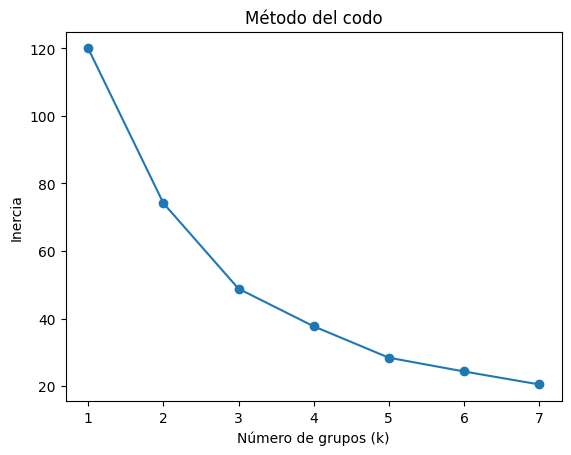

       gasto_mensual  frecuencia_compras
grupo                                   
0         328.699841           16.688439
1         257.771304           13.500917


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

#Clustering/Segmentacion
np.random.seed(7)

grupo_a = pd.DataFrame({
    "gasto_mensual": np.random.normal(300, 50, 60),
    "frecuencia_compras": np.random.normal(15, 3, 60),
})

grupo_b = pd.DataFrame({
    "gasto_mensual": np.random.normal(1200, 150, 60),
    "frecuencia_compras": np.random.normal(3, 1, 60),
})

clientes=pd.concat([grupo_a],ignore_index=True)
#print(clientes.describe())

scaler=StandardScaler()
clientes_escalados=scaler.fit_transform(clientes)

inercias = []
rango_k = range(1, 8)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(clientes_escalados)
    inercias.append(km.inertia_)

plt.plot(rango_k, inercias, marker="o")
plt.xlabel("Número de grupos (k)")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

modelo_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clientes["grupo"] = modelo_kmeans.fit_predict(clientes_escalados)
print(clientes.groupby("grupo").mean())

In [ ]:
import pandas as pd
import numpy as np

n = 300
np.random.seed(55)


datos = pd.DataFrame({
    "meses_como_cliente": np.random.randint(1, 60, n),
    "gasto_mensual_promedio": np.random.uniform(10, 120, n).round(2),
    "num_soporte_contactos": np.random.randint(0, 8, n),
    "usa_app_movil": np.random.randint(0, 2, n),})

riesgo = (
    0.3 * (1 - datos["meses_como_cliente"] / 60)
    + 0.3 * (datos["num_soporte_contactos"] / 8)
    + 0.2 * (1 - datos["gasto_mensual_promedio"] / 120)
    + 0.2 * (1 - datos["usa_app_movil"])
    + np.random.normal(0, 0.1, n)
)

datos["se_de_baja"] = (riesgo > 0.45).astype(int)
datos.head()


,meses_como_cliente,gasto_mensual_promedio,num_soporte_contactos,usa_app_movil,se_de_baja
0,14,19.11,7,0,1
1,27,80.42,1,1,0
2,40,68.10,6,1,1
3,9,35.74,0,0,1
4,30,101.71,6,0,1


In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

nombre_archivo = list(uploaded.keys())[0]

df = pd.read_excel(nombre_archivo, sheet_name=0)
df = df.dropna(axis=1, how="all")  # quita columnas vacías
df.columns = [str(c).strip() for c in df.columns]

col_fecha = [c for c in df.columns if "Fecha" in c][0]
df[col_fecha] = pd.to_datetime(df[col_fecha])
df = df.sort_values(col_fecha).reset_index(drop=True)

cols_numeros = [c for c in df.columns if "Número" in c and "Sorteo" not in c]

print(f"{len(df)} sorteos cargados, del {df[col_fecha].min().date()} al {df[col_fecha].max().date()}")

#Convertir a formato de tabla binaria
rango_numeros=list(range(100))
binaria=pd.DataFrame(0,index=df.index,columns=rango_numeros)

for c in cols_numeros:
  for idx, val in df[c].items():
    if pd.notna(val):
      binaria.loc[idx,int(val)]=1

binaria.head()

##Crear las variable (features)
VENTANA = 20
N_SORTEOS = 500
muestra = binaria.tail(N_SORTEOS).reset_index(drop=True)
X = pd.DataFrame({
    f"freq_{num}": muestra[num].rolling(VENTANA, min_periods=1).mean().shift(1).fillna(0)
    for num in rango_numeros
})
y = muestra
print("X (variables):", X.shape)
print("y (objetivo):", y.shape)

#Entrenar al modelo
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, shuffle=False)

modelo = MultiOutputClassifier(RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)

#Evaluar el modelo
from sklearn.metrics import accuracy_score

exactitud_modelo = accuracy_score(y_test.values.ravel(), pred.ravel())
exactitud_azar = 3 / 100

print(f"Exactitud del modelo: {exactitud_modelo:.2%}")
print(f"Exactitud esperada solo por azar: {exactitud_azar:.2%}")#Evaluar el modelo

from sklearn.metrics import accuracy_score
exactitud_modelo = accuracy_score(y_test.values.ravel(), pred.ravel())
exactitud_azar = 3 / 100

print(f"Exactitud del modelo: {exactitud_modelo:.2%}")
print(f"Exactitud esperada solo por azar: {exactitud_azar:.2%}")




Saving Numeros_Favoreecidos_2019_2025_Loteria_Popular_d95e222a6d (1).xlsx to Numeros_Favoreecidos_2019_2025_Loteria_Popular_d95e222a6d (1) (5).xlsx
569 sorteos cargados, del 2019-01-04 al 2025-12-02
X (variables): (500, 100)
y (objetivo): (500, 100)
Exactitud del modelo: 97.02%
Exactitud esperada solo por azar: 3.00%
Exactitud del modelo: 97.02%
Exactitud esperada solo por azar: 3.00%
